# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [12]:
# Step 1: Choose an industry and ticker symbols
industry = "Retail"
tickers = ['WMT', 'TGT', 'COST', 'KR']

print("Industry:", industry)
print("Tickers:", tickers)

Industry: Retail
Tickers: ['WMT', 'TGT', 'COST', 'KR']


## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [13]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Download adjusted close prices
df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']

/tmp/ipykernel_7392/3952052899.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']
[*********************100%***********************]  4 of 4 completed


In [15]:
df.head()

Ticker,COST,KR,TGT,WMT
Date,,,,
2021-01-04,360.520617,28.854071,153.445577,45.652940
2021-01-05,359.254457,28.871967,156.788690,45.708888
2021-01-06,355.087560,29.247623,163.250809,46.028998
2021-01-07,351.166307,28.988239,165.732235,45.923333
2021-01-08,349.852876,28.549974,167.050532,45.687127


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [16]:
print("Missing values before filling:")
print(df.isnull().sum())

df = df.ffill()

print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values before filling:
Ticker
COST    0
KR      0
TGT     0
WMT     0
dtype: int64

Missing values after filling:
Ticker
COST    0
KR      0
TGT     0
WMT     0
dtype: int64


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [17]:
returns_df = df.pct_change().dropna()
returns_df.head()

Ticker,COST,KR,TGT,WMT
Date,,,,
2021-01-05,-0.003512,0.000620,0.021787,0.001226
2021-01-06,-0.011599,0.013011,0.041215,0.007003
2021-01-07,-0.011043,-0.008869,0.015200,-0.002296
2021-01-08,-0.003740,-0.015119,0.007954,-0.005143
2021-01-11,0.001999,0.003446,0.028987,0.006735


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




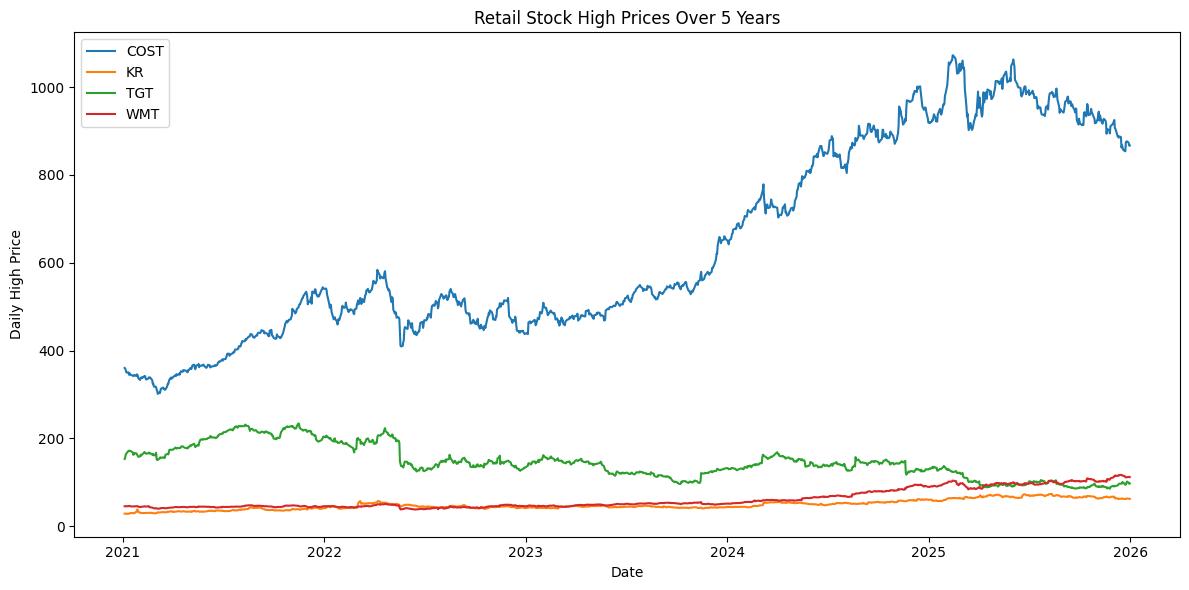

Volatility (Standard Deviation of Daily Returns):
Ticker
COST    0.012537
KR      0.016367
TGT     0.020587
WMT     0.011607
dtype: float64

Correlation Matrix of Daily Returns:
Ticker      COST        KR       TGT       WMT
Ticker                                        
COST    1.000000  0.210488  0.334822  0.498218
KR      0.210488  1.000000  0.140689  0.265400
TGT     0.334822  0.140689  1.000000  0.362155
WMT     0.498218  0.265400  0.362155  1.000000


In [18]:
plt.figure(figsize=(12, 6))
for company in df.columns:
    plt.plot(df.index, df[company], label=company)

plt.title("Retail Stock High Prices Over 5 Years")
plt.xlabel("Date")
plt.ylabel("Daily High Price")
plt.legend()
plt.tight_layout()
plt.show()

volatility = returns_df.std()
print("Volatility (Standard Deviation of Daily Returns):")
print(volatility)

correlation_matrix = returns_df.corr()
print("\nCorrelation Matrix of Daily Returns:")
print(correlation_matrix)

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:
I analyzed the retail industry using five years of stock price data for Walmart (WMT), Target (TGT), Costco (COST), and Kroger (KR). These are all major companies in retail, but they performed pretty differently over time. Costco stood out the most with strong and consistent growth, while Target had more ups and downs and didn’t grow as steadily. Walmart and Kroger were more stable overall, showing slower but more consistent increases compared to the others.

When looking at volatility, Target had the highest level, which means it carries more risk compared to the other stocks. Walmart had the lowest volatility, so it appears to be the most stable option. Costco and Kroger were somewhere in the middle. The correlation results show that all four stocks generally move in the same direction, which makes sense since they are in the same industry, but the relationships are not extremely strong. This means there is still some benefit to spreading investments across different companies instead of putting everything into one.

Based on this, I would recommend investing in the retail industry, but being selective about which companies to choose. Costco looks like the strongest option based on its consistent growth, while Walmart could be a good choice for someone who wants a more stable investment. Target may offer higher potential returns, but it also comes with more risk because of how much it fluctuates. Overall, the industry looks solid, but picking the right companies matters.

To improve this analysis, it would help to include more information like earnings reports, inflation trends, and consumer spending data. Using forecasting models or other types of analysis could also give a better idea of where these stocks might go in the future. This type of analysis should be updated regularly so that decisions stay based on the most current information.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [19]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_14_api.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu